In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
plt.style.use('default')

In [3]:
directorio = "data_sin_SRH"

for archivo in os.listdir(directorio):
    if archivo.endswith(".npy"):
        nombre = os.path.splitext(archivo)[0]
        ruta = os.path.join(directorio, archivo)

        globals()[nombre] = np.load(ruta)

In [4]:
xp_etd = -0.2196e-4 + 9e-4
xn_etd = 0.4392e-4 + 9e-4
xp_Va_max = -0.1396e-4 + 9e-4
xn_Va_max = 0.2792e-4 + 9e-4
idx_xp_etd = np.argmin(np.abs(x_vector_Efield - xp_etd))
idx_xn_etd = np.argmin(np.abs(x_vector_Efield - xn_etd))
idx_xp_Va_max = np.argmin(np.abs(x_vector_Efield - xp_Va_max))
idx_xn_Va_max = np.argmin(np.abs(x_vector_Efield - xn_Va_max))

# PUNTO 10 (PREGUNTAR)

DEVSIM. Solo para la tensi ́on en directa. Calcular y graficar las corrientes de arrastre de
mayoritarios en las QNR en base a la informaci ́on generada por el script de DEVSIM. Utilizar
el campo el ́ectrico y las densidades de portadores. Realizar un gr ́afico para la QNR-N y otro
para la QNR-P. Son en total dos figuras.
Analizar las magnitudes obtenidas en las figuras y justif ́ıquelas.

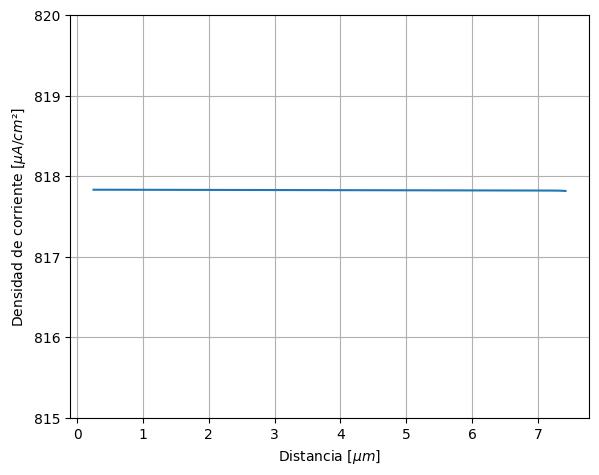

In [6]:
q = 1.602e-19
D_p = 12.4  #Cm²/s
mu_p = 480  #Cm²/Vs
x_mid_Vamax = (x_vector_Efield[1:] + x_vector_Efield[:-1]) / 2
p_mid_Vamax = (p_Va_max[1:] + p_Va_max[:-1]) / 2
E_mid_Vamax = (Efield_Va_max[1:] + Efield_Va_max[:-1]) / 2
Jp_arr_Vamax = q * mu_p * E_mid_Vamax * p_mid_Vamax
plt.figure()
plt.plot(1e4 * x_mid_Vamax[:idx_xp_Va_max-30], 1e6*Jp_arr_Vamax[:idx_xp_Va_max-30], label='Corriente de arrastre')
plt.ylabel(r'Densidad de corriente [$\mu A/cm²$]')
plt.xlabel(r"Distancia [$\mu m$]")
plt.grid()

# 1. Obtén el eje actual
ax = plt.gca()

# 2. Configura el formateador (cambia 'yaxis' por 'xaxis' si es el eje horizontal)
formatter = ax.yaxis.get_major_formatter()

# 3. Desactiva el offset y activa el texto matemático
formatter.set_useOffset(False)
plt.ticklabel_format(style='sci', useOffset=False, axis='both')


plt.tight_layout()
plt.ylim([815,820])
#plt.savefig("res/fig_10_qnr_p.pdf")

plt.show()

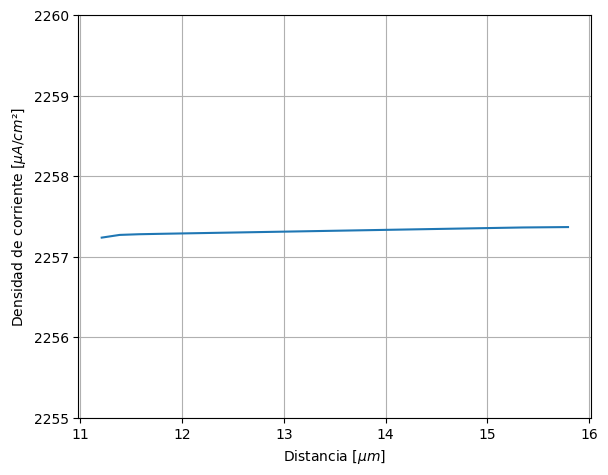

In [7]:
q = 1.602e-19
D_n = 35  #Cm²/s
mu_n = 1350  #Cm²/Vs
x_mid_Vamax = (x_vector_Efield[1:] + x_vector_Efield[:-1]) / 2
n_mid_Vamax = (n_Va_max[1:] + n_Va_max[:-1]) / 2
E_mid_Vamax = (Efield_Va_max[1:] + Efield_Va_max[:-1]) / 2
Jn_arr_Vamax = q * mu_n * E_mid_Vamax * n_mid_Vamax
plt.figure()
plt.plot(1e4 * x_mid_Vamax[idx_xn_Va_max+23:], 1e6*Jn_arr_Vamax[idx_xn_Va_max+23:], label='Corriente de arrastre')
plt.ylabel(r'Densidad de corriente [$\mu A/cm²$]')
plt.xlabel(r"Distancia [$\mu m$]")
plt.grid()

# 1. Obtén el eje actual
ax = plt.gca()

# 2. Configura el formateador (cambia 'yaxis' por 'xaxis' si es el eje horizontal)
formatter = ax.yaxis.get_major_formatter()

# 3. Desactiva el offset y activa el texto matemático
formatter.set_useOffset(False)
plt.ticklabel_format(style='sci', useOffset=False, axis='both')


plt.tight_layout()
plt.ylim([2255,2260])
#plt.savefig("res/fig_10_qnr_n.pdf")

plt.show()